In [13]:
import pandas as pd

# 실제 존재하는 이름표인 'timestamp'와 'EMG_2', 'exercise' 3개를 골라옵니다.
data = pd.read_parquet(
    '../compressed_sensor_data.parquet'
)


In [23]:
ex_data = data[data["filename"] == 'sub1_deadlift_100_plot_and_store_rep_2.5.csv']

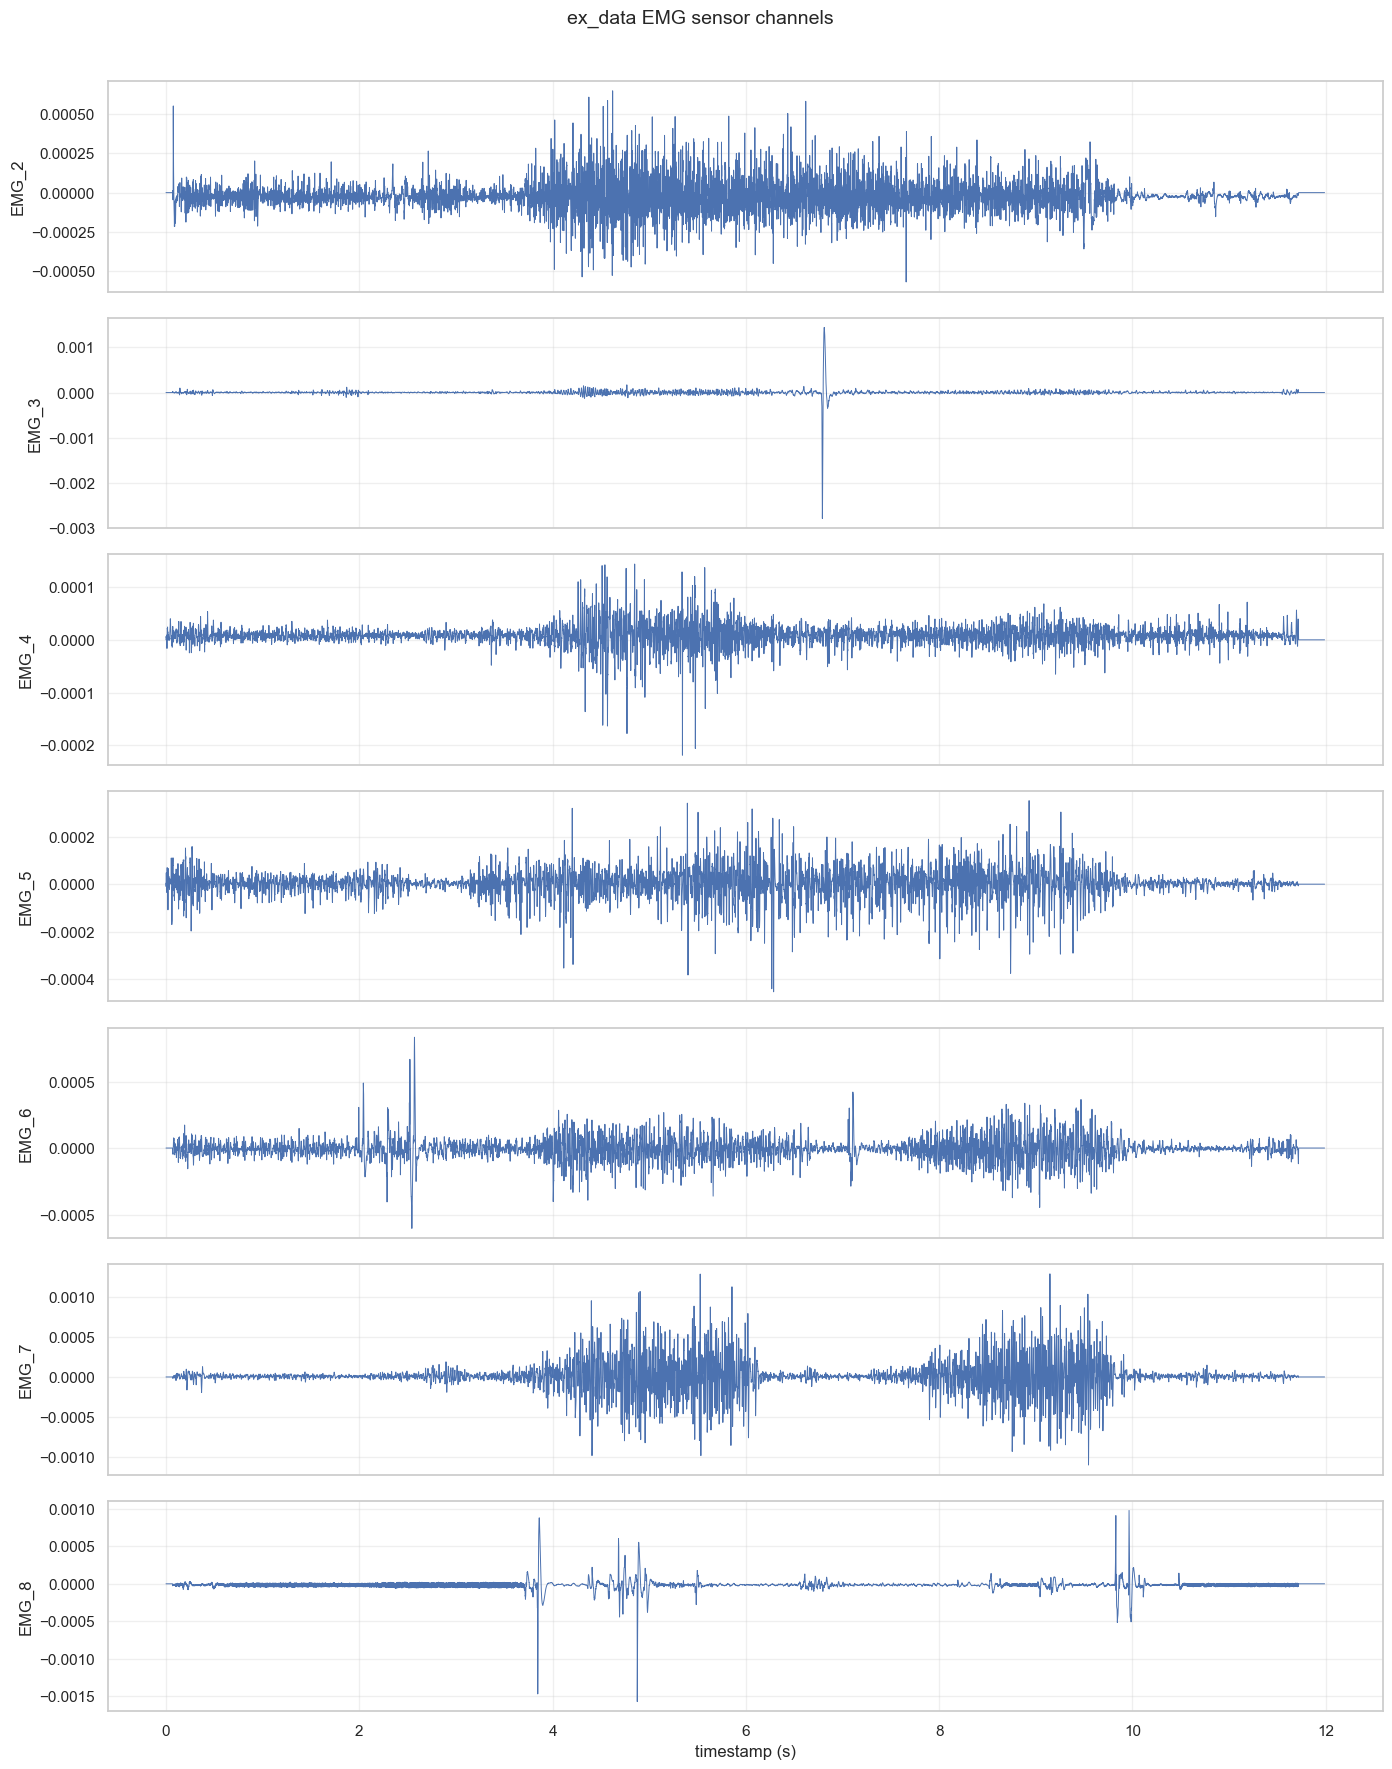

In [25]:
import matplotlib.pyplot as plt

emg_cols = [c for c in ex_data.columns if c.startswith("EMG_") and not c.endswith("_RMS")]
if len(emg_cols) == 0:
    raise ValueError("No EMG columns found in ex_data")

fig, axes = plt.subplots(len(emg_cols), 1, figsize=(14, 2.5 * len(emg_cols)), sharex=True)
if len(emg_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, emg_cols):
    ax.plot(ex_data["timestamp"], ex_data[col], linewidth=0.7)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("timestamp (s)")
fig.suptitle("ex_data EMG sensor channels", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
ex_data

,timestamp,absolute_time,EMG_2,EMG_3,EMG_4,EMG_5,EMG_6,EMG_7,EMG_8,IMU_2_X,...,EMG_5_RMS,EMG_6_RMS,EMG_7_RMS,EMG_8_RMS,filename,subject,exercise,is_1RM,weight_kg,rep
0,0.000000,2025-06-10 13:36:49.853902,0.0,0.0,4.867628e-06,0.000004,0.0,0.0,0.0,0.0,...,1.274438e-05,2.873524e-07,2.504685e-07,4.204044e-07,sub1_deadlift_100_plot_and_store_rep_2.5.csv,sub1,deadlift,True,140,1
1,0.000519,2025-06-10 13:36:49.854421,0.0,0.0,6.210422e-06,-0.000004,0.0,0.0,0.0,0.0,...,1.275073e-05,2.928775e-07,2.568878e-07,4.335079e-07,sub1_deadlift_100_plot_and_store_rep_2.5.csv,sub1,deadlift,True,140,1
2,0.001038,2025-06-10 13:36:49.854940,0.0,0.0,3.860533e-06,-0.000010,0.0,0.0,0.0,0.0,...,1.275116e-05,2.986889e-07,2.633283e-07,4.472369e-07,sub1_deadlift_100_plot_and_store_rep_2.5.csv,sub1,deadlift,True,140,1
3,0.001558,2025-06-10 13:36:49.855459,0.0,0.0,5.035477e-07,-0.000004,0.0,0.0,0.0,0.0,...,1.275826e-05,3.047873e-07,2.697833e-07,4.616003e-07,sub1_deadlift_100_plot_and_store_rep_2.5.csv,sub1,deadlift,True,140,1
4,0.002077,2025-06-10 13:36:49.855978,0.0,0.0,-3.356985e-07,0.000019,0.0,0.0,0.0,0.0,...,1.279398e-05,3.111733e-07,2.762461e-07,4.766071e-07,sub1_deadlift_100_plot_and_store_rep_2.5.csv,sub1,deadlift,True,140,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23083,11.985404,2025-06-10 13:37:01.839305,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,...,2.767114e-10,5.745719e-09,1.328729e-09,2.955161e-09,sub1_deadlift_100_plot_and_store_rep_2.5.csv,sub1,deadlift,True,140,1
23084,11.985923,2025-06-10 13:37:01.839825,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,...,2.698319e-10,5.700022e-09,1.293422e-09,2.866685e-09,sub1_deadlift_100_plot_and_store_rep_2.5.csv,sub1,deadlift,True,140,1
23085,11.986443,2025-06-10 13:37:01.840344,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,...,2.629744e-10,5.650445e-09,1.259559e-09,2.780350e-09,sub1_deadlift_100_plot_and_store_rep_2.5.csv,sub1,deadlift,True,140,1
23086,11.986961,2025-06-10 13:37:01.840863,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,...,2.561469e-10,5.597133e-09,1.227149e-09,2.696212e-09,sub1_deadlift_100_plot_and_store_rep_2.5.csv,sub1,deadlift,True,140,1


In [9]:
data_y = data['exercise']
data_X = data.drop(columns=['exercise'])

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# features should be numeric; drop non-numeric columns in data_X
X = data_X.select_dtypes(include=['number'])
y = data_y.copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist'
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_pred = model.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, target_names=le.classes_))

c:\Users\akska\anaconda3\envs\AIHCLAB_da\lib\site-packages\xgboost\training.py:200: UserWarning: [16:21:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validation accuracy: 0.9494427684683092
              precision    recall  f1-score   support

 barbellcurl       0.94      0.91      0.93    280904
   barbelrow       0.90      0.87      0.88    308032
  benchpress       0.99      0.99      0.99    405964
         bte       0.95      0.91      0.93    315921
    deadlift       0.90      0.96      0.93    448677
        dips       0.98      0.98      0.98    270130
 latpulldown       0.97      0.94      0.96    359788
         ohp       0.92      0.96      0.94    404810
      pullup       0.98      0.98      0.98    192785
      pushup       1.00      0.99      1.00    242616

    accuracy                           0.95   3229627
   macro avg       0.95      0.95      0.95   3229627
weighted avg       0.95      0.95      0.95   3229627

